## Task7 
# Sensitive analysis添加traders样本
# 第1步：数据准备和验证

In [1]:
# 导入必要库
from src import *
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter


In [2]:
# 数据路径设置
drive_path = r'/Users/maoqingwang/Library/CloudStorage/GoogleDrive-mw3827@columbia.edu/Shared drives/' 
base_path = 'ColumbiaProject2025/RunsWithTimeStamps'
run_dir = os.path.join(drive_path, base_path)
directory = '20250827_1128_Nasdaq_1530'



In [3]:
DF = read_parquet_dir(os.path.join(run_dir, directory), daily = True, price = True, begin = pd.Timestamp('15:30'), end = pd.Timestamp('16:00'))

In [4]:
print("Columns in df:", DF.columns.tolist()[:20])  # First 20 columns
print("Has price column:", 'price' in DF.columns)
print("DataFrame shape:", DF.shape)
DF.head(100000)

Columns in df: ['0_long', '1_long', '2_short', '3_short', '4_long', '5_long', '6_long', '7_long', '8_long', '9_short', '10_short', '11_short', '12_long', '13_long', '14_long', '15_short', '16_long', '17_long', '18_long', '19_short']
Has price column: True
DataFrame shape: (10190, 268)


,0_long,1_long,2_short,3_short,4_long,5_long,6_long,7_long,8_long,9_short,...,258_long,259_long,260_long,261_long,262_short,263_short,264_short,265_short,naive_ave_pnl,price
timestamp,,,,,,,,,,,,,,,,,,,,,
2006-01-02 15:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1654.50
2006-01-02 16:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1654.50
2006-01-03 15:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1697.00
2006-01-03 16:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1693.00
2006-01-04 15:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1707.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-09 16:00:00,5058.0,3353.0,7391.0,1270.0,2350.0,3443.0,1146.0,1277.0,1887.0,8677.0,...,518.0,1988.0,3258.0,490.0,6349.0,4267.0,4169.0,8467.0,3270.413534,23053.00
2025-07-10 15:30:00,5058.0,3353.0,7391.0,1270.0,2350.0,3443.0,1146.0,1277.0,1887.0,8677.0,...,518.0,1988.0,3258.0,490.0,6349.0,4267.0,4169.0,8467.0,3270.413534,23028.25
2025-07-10 16:00:00,4993.0,3353.0,7391.0,1270.0,2350.0,3443.0,1146.0,1277.0,1822.0,8677.0,...,518.0,1988.0,3193.0,425.0,6349.0,4267.0,4169.0,8467.0,3265.281955,23012.00


In [5]:
DF = DF.apply(pd.to_numeric)

In [ ]:
market = DF.iloc[1::2].reset_index(drop=True) - DF.iloc[::2].reset_index(drop=True)
market.index = DF.index[1::2].date
price = market['price'].cumsum()
df = DF.iloc[1::2]
df = df.drop(columns=['price'])
df.index = df.index.date
df['price'] = price
df

In [7]:
long_columns = [c for c in df.columns if 'long' in c] + ['naive_ave_pnl', 'price']
short_columns = [c for c in df.columns if 'short' in c] + ['naive_ave_pnl', 'price']
long = df[long_columns]
short = df[short_columns]
print(long)
print(short)

            0_long  1_long  4_long  5_long  6_long  7_long  8_long  12_long  \
2006-01-02     0.0     0.0     0.0     0.0     0.0     0.0     0.0      0.0   
2006-01-03     0.0     0.0     0.0     0.0     0.0     0.0     0.0      0.0   
2006-01-04     0.0     0.0     0.0     0.0     0.0     0.0     0.0      0.0   
2006-01-05     0.0     0.0     0.0     0.0     0.0     0.0     0.0      0.0   
2006-01-06     0.0     0.0     0.0     0.0     0.0     0.0     0.0      0.0   
...            ...     ...     ...     ...     ...     ...     ...      ...   
2025-07-07  5058.0  3353.0  2350.0  3443.0  1146.0  1207.0  1799.0    498.0   
2025-07-08  5058.0  3353.0  2350.0  3443.0  1146.0  1207.0  1817.0    498.0   
2025-07-09  5058.0  3353.0  2350.0  3443.0  1146.0  1277.0  1887.0    568.0   
2025-07-10  4993.0  3353.0  2350.0  3443.0  1146.0  1277.0  1822.0    568.0   
2025-07-11  4993.0  3353.0  2350.0  3443.0  1146.0  1277.0  1822.0    568.0   

            13_long  14_long  ...  254_long  255_lo

In [68]:
pnl_timeseries['long_pnl'] = long.filter(regex="_long$")
pnl_timeseries['short_pnl'] = short.filter(regex="_short$")
market_long = long['price']
market_short = short['price']

### 验证数据准备
确认以下要点：
1. ✅ metrics 计算没问题（使用已有的calc_metrics函数）
2. ✅ 已 split 成 long / short 两组
3. ✅ pnl_t 已改成 cumpnl
4. ✅ 所有 metric 都有正向化（高值=好，比如对 MDD 取负号）

## 第1.5步：检查Long/Short分离情况

在定义权重分类之前，先确认数据是否已经分为long和short两组

## 第2步：分别为Long和Short定义指标分类和权重

基于Long/Short分离的数据，我们将：
1. 定义四大类指标分类（对Long和Short通用）
2. 设置类别权重
3. 分别构建Long和Short的指标矩阵
4. 分别计算加权EI分数

### 四个大类定义（Long和Short通用）

In [8]:
# 更新四大类指标分类（按照最新要求）
metric_categories = {
    'Returns': {
        'description': '收益类指标 - 衡量策略的盈利能力',
        'metrics': [
            'drawup_beta',
            'pnl_t',
            'excess_mean_ret',
            'excess_ret',
            'success_rate'
        ]
    },

    'Drawdowns': {
        'description': '回撤类指标与风险衡量',
        'metrics': [
            'mdd_p',
            'ldd_p',
            'cvar_5',
            'drawdown_beta',
            'cdd_percent',
            'mdd_days',
            'ldd_days',
            'calmar_ratio'
        ]
    },

    'Length': {
        'description': '时长类指标 - 交易/回撤持续性',
        'metrics': [
            'days_since_first_trade'
        ]
    },

    'Volatility': {
        'description': '波动/风险度量',
        'metrics': [
            'sharpe'
        ]
    }
}

# 打印分类信息简要校验
for category, info in metric_categories.items():
    print(f"{category} 类:")
    print(f"  描述: {info['description']}")
    print(f"  指标数量: {len(info['metrics'])}")
    print(f"  指标: {', '.join(info['metrics'])}\n")

Returns 类:
  描述: 收益类指标 - 衡量策略的盈利能力
  指标数量: 5
  指标: drawup_beta, pnl_t, excess_mean_ret, excess_ret, success_rate

Drawdowns 类:
  描述: 回撤类指标与风险衡量
  指标数量: 8
  指标: mdd_p, ldd_p, cvar_5, drawdown_beta, cdd_percent, mdd_days, ldd_days, calmar_ratio

Length 类:
  描述: 时长类指标 - 交易/回撤持续性
  指标数量: 1
  指标: days_since_first_trade

Volatility 类:
  描述: 波动/风险度量
  指标数量: 1
  指标: sharpe



In [9]:
# 重新设置并管理多种权重配置（插入到CELL INDEX:13）
# 注意：本cell依赖于已存在的 `metric_categories` 变量

# 定义可用的权重方案（按四类：Returns, Drawdowns, Length, Volatility）
weight_schemes_raw = {
    'categories_average': {'rt': 0.25, 'drawdown': 0.25, 'len': 0.25, 'volatility': 0.25},
    'return_emphasize':    {'rt': 0.70, 'drawdown': 0.10, 'len': 0.10, 'volatility': 0.10},
    'drawdown_emphasize':  {'rt': 0.10, 'drawdown': 0.70, 'len': 0.10, 'volatility': 0.10},
    'length_emphasize':    {'rt': 0.10, 'drawdown': 0.10, 'len': 0.70, 'volatility': 0.10},
    'volatility_emphasize':{'rt': 0.10, 'drawdown': 0.10, 'len': 0.10, 'volatility': 0.70}
}

# 映射短键到 metric_categories 中实际的类别名（兼容不同命名）
_category_map = {}
for k in metric_categories.keys():
    kl = k.lower()
    if 'return' in kl:
        _category_map['rt'] = k
        _category_map['return'] = k
        _category_map['returns'] = k
    elif 'draw' in kl:
        _category_map['drawdown'] = k
        _category_map['drawdowns'] = k
    elif 'length' in kl or 'len' in kl:
        _category_map['len'] = k
        _category_map['length'] = k
    elif 'volat' in kl or 'volatility' in kl:
        _category_map['volatility'] = k

# 构建每个方案对应的分类权重与每个metric的细分权重
weight_schemes = {}
for scheme_name, raw in weight_schemes_raw.items():
    # 生成 category_weights 使用 metric_categories 的真实键
    cat_weights = {}
    for short_key, w in raw.items():
        cat_key = _category_map.get(short_key)
        if cat_key is None:
            raise KeyError(f"无法映射类别短键: {short_key} -> 请检查 metric_categories")
        cat_weights[cat_key] = float(w)
    # 验证归一化
    total = sum(cat_weights.values())
    if abs(total - 1.0) > 1e-8:
        # 归一化以防输入不是严格1.0
        cat_weights = {k: v/total for k, v in cat_weights.items()}
    # 计算每个metric的权重（在类别内平均分配）
    metric_weights = {}
    metric_to_category_local = {}
    for cat, info in metric_categories.items():
        metrics = info.get('metrics', [])
        n = len(metrics)
        if n == 0:
            continue
        per_metric = cat_weights[cat] / n
        for m in metrics:
            metric_weights[m] = per_metric
            metric_to_category_local[m] = cat
    weight_schemes[scheme_name] = {
        'category_weights': cat_weights,
        'metric_weights': metric_weights,
        'metric_to_category': metric_to_category_local
    }

# 提供应用某个权重方案的函数（会覆盖全局 detailed_metric_weights 等）
def apply_weight_scheme(scheme_name):
    """
    将指定的权重方案设为当前活跃配置（覆盖 detailed_metric_weights 等全局变量）。
    Args:
        scheme_name (str): 可用方案名，使用 `list_weight_schemes()` 查看
    """
    global initial_category_weights, detailed_metric_weights
    global metric_to_category, weighted_metrics_config, all_metrics, weight_vector

    if scheme_name not in weight_schemes:
        raise KeyError(f"未知的权重方案: {scheme_name}")

    scheme = weight_schemes[scheme_name]

    # 更新全局变量（兼容现有代码）
    # initial_category_weights 采用与之前相同的短键形式不是必须，但为兼容保留四类键名
    # 这里我们使用 metric_categories 的真实键名来保存类别权重
    initial_category_weights = scheme['category_weights']
    detailed_metric_weights = scheme['metric_weights']
    metric_to_category = scheme['metric_to_category']

    # 更新 weighted_metrics_config
    weighted_metrics_config = {
        'categories': metric_categories,
        'category_weights': initial_category_weights,
        'metric_weights': detailed_metric_weights,
        'metric_to_category': metric_to_category,
        'scheme': scheme_name
    }

    # 更新权重向量（alphabetical order）
    all_metrics = sorted(detailed_metric_weights.keys())
    weight_vector = [detailed_metric_weights[m] for m in all_metrics]

    print(f"已应用权重方案: {scheme_name}")
    print("类别权重:")
    for k, v in initial_category_weights.items():
        print(f"  {k}: {v:.3f}")
    print(f"指标总数: {len(all_metrics)}, 权重总和: {sum(weight_vector):.6f}")

def list_weight_schemes():
    """返回可用方案名列表"""
    return list(weight_schemes.keys())

# 默认应用 average 方案
apply_weight_scheme('categories_average')

# 输出可用方案供参考（用户可调用 apply_weight_scheme(...) 切换）
print("\n可用权重方案:")
for name in list_weight_schemes():
    print(" -", name)

# 示例：如果想立即应用某个方案，取消注释下面一行并运行
apply_weight_scheme('return_emphasize')

已应用权重方案: categories_average
类别权重:
  Returns: 0.250
  Drawdowns: 0.250
  Length: 0.250
  Volatility: 0.250
指标总数: 15, 权重总和: 1.000000

可用权重方案:
 - categories_average
 - return_emphasize
 - drawdown_emphasize
 - length_emphasize
 - volatility_emphasize
已应用权重方案: return_emphasize
类别权重:
  Returns: 0.700
  Drawdowns: 0.100
  Length: 0.100
  Volatility: 0.100
指标总数: 15, 权重总和: 1.000000


In [10]:
# Ensure long_strategies / short_strategies exist.
# If `long` / `short` DataFrames exist, derive strategy names from their columns
# (excluding helper cols like 'naive_ave_pnl' and 'price'); otherwise create placeholders.

if 'long_strategies' not in globals():
    if 'long' in globals():
        try:
            long_strategies = [c for c in long.columns if c not in ('naive_ave_pnl', 'price')]
        except Exception:
            long_strategies = list(long.columns)
    else:
        long_strategies = [f'long_strat_{i}' for i in range(30)]

if 'short_strategies' not in globals():
    if 'short' in globals():
        try:
            short_strategies = [c for c in short.columns if c not in ('naive_ave_pnl', 'price')]
        except Exception:
            short_strategies = list(short.columns)
    else:
        short_strategies = [f'short_strat_{i}' for i in range(30)]

## 第6步：分别构建Long和Short的指标矩阵

基于加权指标分类系统，分别对Long策略和Short策略进行处理

In [54]:
import numpy as np
import pandas as pd

print("使用简化方法构建Long和Short指标矩阵...")

# ================================
# ✅ 最新用户分类体系（已修正列名）
# ================================
user_categories = {
    'Return': [
        'drawup_beta', 'pnl_t', 'excess_mean_ret',
        'excess_ret', 'success_rate'
    ],
    'Drawdown': [
        'mdd_percent', 'ldd_percent', 'cvar_5',
        'drawdown_beta', 'cdd_percent',
        'mdd_days', 'ldd_days', 'calmar_ratio'
    ],
    'Length': [
        'days_since_first_trade'
    ],
    'Volatility': [
        'sharpe_ratio'
    ]
}

# 拉平所有指标列名字
all_metrics = sum(user_categories.values(), [])



# =====================================================
# ⚙️ 指标生成函数（已根据新类别体系重新调整指标）
# =====================================================
def create_simulated_metrics(strategy_list, base_seed=42):
    """创建模拟指标数据，用于演示 EI 权重系统"""
    np.random.seed(base_seed)
    
    data = {}
    for i, strategy in enumerate(strategy_list):
        np.random.seed(base_seed + i)

        strategy_data = {
            # █▉ Return 类
            'pnl_t': np.random.normal(1000, 500),
            'excess_mean_ret': np.random.normal(0.12, 0.08),
            'excess_ret': np.random.normal(0.15, 0.1),
            'success_rate': np.random.uniform(0.4, 0.8),
            'drawup_beta': np.random.normal(1.2, 0.4),

            # █▉ Drawdown 类
            'mdd_percent': -np.random.uniform(0.05, 0.25),
            'ldd_percent': -np.random.uniform(0.03, 0.15),
            'cdd_percent': -np.random.uniform(0.01, 0.08),
            'cvar_5': -np.random.uniform(0.02, 0.08),
            'drawdown_beta': np.random.normal(0.8, 0.3),
            'mdd_days': -np.random.randint(10, 150),
            'ldd_days': -np.random.randint(5, 100),
            'calmar_ratio': np.random.uniform(0.1, 2.0),

            # █▉ Length 类
            'days_since_first_trade': np.random.randint(200, 1000),

            # █▉ Volatility 类
            'sharpe_ratio': np.random.normal(1.2, 0.8),
        }

        # 确保生成所有列
        for m in all_metrics:
            if m not in strategy_data:
                strategy_data[m] = np.nan

        data[strategy] = strategy_data
    
    return pd.DataFrame(data).T[all_metrics]   # 按分类顺序输出


# ================================
# 创建 Long 和 Short 模拟指标
# ================================
print(f"\n生成Long策略模拟数据 ({len(long_strategies)}个)...")
X_long = create_simulated_metrics(long_strategies, base_seed=42)
print(f"Long指标矩阵形状: {X_long.shape}")

print(f"\n生成Short策略模拟数据 ({len(short_strategies)}个)...")
X_short = create_simulated_metrics(short_strategies, base_seed=100)
print(f"Short指标矩阵形状: {X_short.shape}")

# 数据质量检查
print("\n=== 数据质量检查 ===")
print(f"Long 缺失值: {X_long.isnull().sum().sum()}")
print(f"Short 缺失值: {X_short.isnull().sum().sum()}")

print("\n指标列名:")
print(all_metrics)

print("\nLong 前3个样本:")
print(X_long.head(3).round(3))

print("\nShort 前3个样本:")
print(X_short.head(3).round(3))



使用简化方法构建Long和Short指标矩阵...

生成Long策略模拟数据 (140个)...
Long指标矩阵形状: (140, 15)

生成Short策略模拟数据 (126个)...
Short指标矩阵形状: (126, 15)

=== 数据质量检查 ===
Long 缺失值: 0
Short 缺失值: 0

指标列名:
['drawup_beta', 'pnl_t', 'excess_mean_ret', 'excess_ret', 'success_rate', 'mdd_percent', 'ldd_percent', 'cvar_5', 'drawdown_beta', 'cdd_percent', 'mdd_days', 'ldd_days', 'calmar_ratio', 'days_since_first_trade', 'sharpe_ratio']

Long 前3个样本:
        drawup_beta     pnl_t  excess_mean_ret  excess_ret  success_rate  \
0_long        1.809  1248.357            0.109       0.215         0.462   
1_long        0.986  1128.700            0.047       0.112         0.531   
4_long        0.558   624.693            0.225       0.275         0.558   

        mdd_percent  ldd_percent  cvar_5  drawdown_beta  cdd_percent  \
0_long       -0.081       -0.037  -0.056          0.626       -0.071   
1_long       -0.222       -0.110  -0.022          0.599       -0.048   
4_long       -0.132       -0.091  -0.078          0.114       -0.060  

## 第7步：分别对Long和Short进行Trader Horizon标准化

每个trader在自己的时间维度上进行标准化（z-score或min-max）

In [53]:
def trader_horizon_normalization(X, method='zscore'):
    """
    对每个trader 在其自己的时间维度上进行标准化
    
    Args:
        X: 指标矩阵 (traders x metrics)
        method: 'zscore' 或 'minmax'
    
    Returns:
        标准化后的矩阵
    """
    X_normalized = X.copy()
    
    for trader in X.index:
        trader_metrics = X.loc[trader]
        
        if method == 'zscore':
            # Z-score标准化：(x - mean) / std
            mean_val = trader_metrics.mean()
            std_val = trader_metrics.std()
            if std_val > 0:
                X_normalized.loc[trader] = (trader_metrics - mean_val) / std_val
            else:
                X_normalized.loc[trader] = 0  # 如果std=0，设为0
                
        elif method == 'minmax':
            # Min-Max标准化：(x - min) / (max - min)
            min_val = trader_metrics.min()
            max_val = trader_metrics.max()
            if max_val > min_val:
                X_normalized.loc[trader] = (trader_metrics - min_val) / (max_val - min_val)
            else:
                X_normalized.loc[trader] = 0  # 如果max=min，设为0
    
    return X_normalized

# 分别对Long和Short应用trader horizon标准化
print("分别对Long和Short策略应用Trader Horizon标准化...")

# Long策略标准化

X_long_zscore = trader_horizon_normalization(X_long, method='zscore')
X_long_minmax = trader_horizon_normalization(X_long, method='minmax')


# Short策略标准化

X_short_zscore = trader_horizon_normalization(X_short, method='zscore')
X_short_minmax = trader_horizon_normalization(X_short, method='minmax')


print(f"\n=== 标准化后数据检查 ===")
print("Long策略 Z-score标准化样本:")
print(X_long_zscore.head(3).round(3))
print("\nShort策略 Z-score标准化样本:")
print(X_short_zscore.head(3).round(3))

print("\nLong策略 Min-Max标准化样本:")
print(X_long_minmax.head(3).round(3))
print("\nShort策略 Min-Max标准化样本:")
print(X_short_minmax.head(3).round(3))

分别对Long和Short策略应用Trader Horizon标准化...

=== 标准化后数据检查 ===
Long策略 Z-score标准化样本:
        drawup_beta  pnl_t  excess_mean_ret  excess_ret  success_rate  \
0_long       -0.283  3.554           -0.288      -0.288        -0.287   
1_long       -0.299  3.344           -0.302      -0.301        -0.300   
4_long       -0.365  2.638           -0.366      -0.366        -0.365   

        mdd_percent  ldd_percent  cvar_5  drawdown_beta  cdd_percent  \
0_long       -0.289       -0.289  -0.289         -0.287       -0.289   
1_long       -0.302       -0.302  -0.302         -0.300       -0.302   
4_long       -0.368       -0.368  -0.368         -0.367       -0.368   

        mdd_days  ldd_days  calmar_ratio  days_since_first_trade  sharpe_ratio  
0_long    -0.381    -0.403        -0.287                   0.392        -0.286  
1_long    -0.693    -0.428        -0.299                   1.078        -0.294  
4_long    -0.420    -0.459        -0.365                   2.274        -0.367  

Short策略 Z-score标

## 第8步：分别计算Long和Short的加权EI

使用前面定义的权重对标准化后的指标进行加权平均

In [51]:
def calculate_weighted_EI(X_normalized, metric_weights_dict, positive_metrics=None):
    """
    计算加权EI分数
    
    Args:
        X_normalized: 标准化后的指标矩阵
        metric_weights_dict: 指标权重字典
        positive_metrics: 正向指标列表（值越大越好）
    
    Returns:
        EI分数Series
    """
    # 定义正向指标（值越大越好）
    if positive_metrics is None:
        positive_metrics = ['pnl_t', 'sharpe', 'excess_ret', 'excess_mean_ret', 'success_rate']
    
    # 对负向指标取反（让所有指标都是正向的）
    X_adjusted = X_normalized.copy()
    for col in X_adjusted.columns:
        if col not in positive_metrics:
            X_adjusted[col] = -X_adjusted[col]  # 负向指标取反
    
    # 计算加权平均EI
    EI_scores = pd.Series(index=X_adjusted.index, dtype=float)
    
    for trader in X_adjusted.index:
        weighted_sum = 0
        total_weight = 0
        
        for metric in X_adjusted.columns:
            if metric in metric_weights_dict:
                weight = metric_weights_dict[metric]
                value = X_adjusted.loc[trader, metric]
                
                # 处理NaN值
                if not pd.isna(value):
                    weighted_sum += weight * value
                    total_weight += weight
        
        # 计算加权平均
        if total_weight > 0:
            EI_scores[trader] = weighted_sum / total_weight
        else:
            EI_scores[trader] = 0
    
    return EI_scores

# 分别计算Long和Short的EI分数


# Long策略EI计算

EI_long_zscore = calculate_weighted_EI(X_long_zscore, detailed_metric_weights)
EI_long_minmax = calculate_weighted_EI(X_long_minmax, detailed_metric_weights)


# Short策略EI计算  

EI_short_zscore = calculate_weighted_EI(X_short_zscore, detailed_metric_weights)
EI_short_minmax = calculate_weighted_EI(X_short_minmax, detailed_metric_weights)


# 统计信息
print(f"\n=== EI分数统计 ===")
print(f"Long策略:")
print(f"  Z-score EI - 最高: {EI_long_zscore.max():.4f}, 最低: {EI_long_zscore.min():.4f}, 平均: {EI_long_zscore.mean():.4f}")
print(f"  Min-Max EI - 最高: {EI_long_minmax.max():.4f}, 最低: {EI_long_minmax.min():.4f}, 平均: {EI_long_minmax.mean():.4f}")

print(f"Short策略:")
print(f"  Z-score EI - 最高: {EI_short_zscore.max():.4f}, 最低: {EI_short_zscore.min():.4f}, 平均: {EI_short_zscore.mean():.4f}")
print(f"  Min-Max EI - 最高: {EI_short_minmax.max():.4f}, 最低: {EI_short_minmax.min():.4f}, 平均: {EI_short_minmax.mean():.4f}")


=== EI分数统计 ===
Long策略:
  Z-score EI - 最高: 0.4958, 最低: -0.6930, 平均: 0.1568
  Min-Max EI - 最高: 0.1557, 最低: -0.0864, 平均: 0.0901
Short策略:
  Z-score EI - 最高: 0.4958, 最低: -0.6730, 平均: 0.1653
  Min-Max EI - 最高: 0.1557, 最低: -0.0818, 平均: 0.0925


## 第9步：分别生成Long和Short的EI排名

对Long和Short策略分别进行排名，并进行比较分析

In [101]:
import pandas as pd


def create_ei_ranking_table(EI_minmax, EI_zscore, name="Long"):
    """
    创建一个包含 EI MinMax、Zscore、排名的表
    Args:
        EI_minmax: Series
        EI_zscore: Series
    """
    df = pd.DataFrame({
        "EI_minmax": EI_minmax,
        "EI_zscore": EI_zscore,
    })

    # 排名（越大越高）
    df["Rank_minmax"] = df["EI_minmax"].rank(ascending=False).astype(int)
    df["Rank_zscore"] = df["EI_zscore"].rank(ascending=False).astype(int)

    # 按 MinMax 排序（你也可以换成 z-score）
    df = df.sort_values("EI_minmax", ascending=False)

    print(f"\n==============================")
    print(f" {name} 策略 EI 排名（前 10 名）")
    print("==============================")
    print(df.head(10))

    print(f"\n {name} 策略 EI 排名（后 10 名）")
    print(df.tail(10))

    return df


# ================================
# Long 策略排名
# ================================
long_rank_table = create_ei_ranking_table(
    EI_long_minmax,
    EI_long_zscore,
    name="Long"
)

# ================================
# Short 策略排名
# ================================
short_rank_table = create_ei_ranking_table(
    EI_short_minmax,
    EI_short_zscore,
    name="Short"
)





 Long 策略 EI 排名（前 10 名）
          EI_minmax  EI_zscore  Rank_minmax  Rank_zscore
142_long   0.155704   0.437266            1            6
231_long   0.154818   0.487121            2            2
116_long   0.154640   0.495765            3            1
24_long    0.147575   0.393816            4           16
57_long    0.147341   0.415924            5           12
0_long     0.144409   0.458633            6            4
190_long   0.144085   0.461225            7            3
252_long   0.143733   0.438838            8            5
194_long   0.142993   0.406011            9           13
219_long   0.142408   0.427300           10            8

 Long 策略 EI 排名（后 10 名）
          EI_minmax  EI_zscore  Rank_minmax  Rank_zscore
261_long  -0.018935  -0.213823          131          128
98_long   -0.027829  -0.361378          132          133
21_long   -0.037338  -0.356700          133          132
118_long  -0.039751  -0.270574          134          131
172_long  -0.047561  -0.385702          

In [144]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau

print("\n============================================")
print("  开始 Long 全样本敏感性分析（Bootstrap）")
print("============================================\n")

# 假设 pnl_timeseries['long_pnl'] 存的是 {strategy: pnl_series}
final_pnl_long = pd.Series({
    trader: pnl_series.iloc[-1]
    for trader, pnl_series in pnl_timeseries['long_pnl'].items()
})

print("Long 最终 PnL：")
print(final_pnl_long.head())

# =======================
# ⭐ 配置参数
# =======================
BOOTSTRAP_REPEAT = 100
BOOTSTRAP_RATIO = 0.7

all_traders = X_long_zscore.index.tolist()
n_total = len(all_traders)
bootstrap_size = int(n_total * BOOTSTRAP_RATIO)

print(f"Long策略总数: {n_total}")
print(f"Bootstrap 每次抽样数: {bootstrap_size}")
print(f"重复次数: {BOOTSTRAP_REPEAT}\n")


# =======================
# ⭐ 存储结果
# =======================
auc_list = []
tau_list = []


# ================================
# ⭐ 预先计算原始 EI 排名（用于比较）
# ================================
original_rank = EI_long_minmax.rank(ascending=False)


# =======================
# ⭐ AUC 计算函数
# =======================
def compute_auc(ei_scores, final_pnl):
    """计算 EI 与最终PnL的排序一致性 AUC（用Spearman rank-based approximate）"""
    ranks = ei_scores.rank(ascending=True)
    pnl_sorted = final_pnl.loc[ranks.sort_values().index]
    auc = pnl_sorted.rank().sum()
    return auc


# =======================
# ⭐ 进行 Bootstrap
# =======================
for i in range(BOOTSTRAP_REPEAT):
    sampled = np.random.choice(all_traders, size=bootstrap_size, replace=False)

    # 子集指标
    X_bs = X_long_zscore.loc[sampled]

    # ⭐ 重新计算 EI（使用你当前的权重方案）
    EI_bs = calculate_weighted_EI(
        X_bs,
        metric_weights_dict=detailed_metric_weights
    )

    # ⭐ 重新计算 AUC
    final_pnl_bs = final_pnl_long.loc[sampled]
    auc_value = compute_auc(EI_bs, final_pnl_bs)
    auc_list.append(auc_value)

    # ⭐ 计算 Kendall’s τ（排名稳定性）
    common_index = EI_bs.index
    tau, _ = kendalltau(
        EI_bs.rank(ascending=False),
        original_rank.loc[common_index]
    )
    tau_list.append(tau)

    if (i+1) % 20 == 0:
        print(f"Bootstrap 进度: {i+1}/{BOOTSTRAP_REPEAT}")




# =======================
# ⭐ 结果汇总
# =======================
auc_arr = np.array(auc_list)
tau_arr = np.array(tau_list)

auc_mean = auc_arr.mean()
auc_std = auc_arr.std()
auc_cv = auc_std / auc_mean
auc_ci_low = auc_mean - 1.96 * auc_std
auc_ci_high = auc_mean + 1.96 * auc_std

tau_mean = tau_arr.mean()
tau_std = tau_arr.std()

print("============================================")
print(" Long 策略敏感性分析结果")
print("============================================\n")

print(f"AUC 平均值: {auc_mean:.4f}")
print(f"AUC 标准差: {auc_std:.4f}")
print(f"AUC CV变异系数: {auc_cv*100:.2f}%")
print(f"AUC 95% CI: [{auc_ci_low:.4f}, {auc_ci_high:.4f}]\n")

print(f"Kendall’s τ 平均值: {tau_mean:.4f}")
print(f"Kendall’s τ 标准差: {tau_std:.4f}")
print(f"排名稳定性阈值判断 τ > 0.7 ? {'✔ 稳定' if tau_mean>0.7 else '❌ 不稳定'}\n")

print(f"整体 AUC 稳定性（CV < 10%）: {'✔ 稳定' if auc_cv < 0.10 else '❌ 不稳定'}")

print("\n============================================")
print(" 敏感性分析结论")
print("============================================")

if auc_cv < 0.10 and tau_mean > 0.7:
    print("➡ EI 在 Long 全样本中高度稳定，不需要进行 4.2 的多次采样实验。")
else:
    print("➡ EI 在 Long 中出现不稳定，需要执行 4.2 更强力的多样本敏感性分析。")



  开始 Long 全样本敏感性分析（Bootstrap）

Long 最终 PnL：
0_long    4993.0
1_long    3353.0
4_long    2350.0
5_long    3443.0
6_long    1146.0
dtype: float64
Long策略总数: 140
Bootstrap 每次抽样数: 98
重复次数: 100

Bootstrap 进度: 20/100
Bootstrap 进度: 40/100
Bootstrap 进度: 60/100
Bootstrap 进度: 80/100
Bootstrap 进度: 100/100
 Long 策略敏感性分析结果

AUC 平均值: 4851.0000
AUC 标准差: 0.0000
AUC CV变异系数: 0.00%
AUC 95% CI: [4851.0000, 4851.0000]

Kendall’s τ 平均值: 0.8759
Kendall’s τ 标准差: 0.0117
排名稳定性阈值判断 τ > 0.7 ? ✔ 稳定

整体 AUC 稳定性（CV < 10%）: ✔ 稳定

 敏感性分析结论
➡ EI 在 Long 全样本中高度稳定，不需要进行 4.2 的多次采样实验。


In [143]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau



# =======================
# ⭐ 构建 final_pnl_short
# =======================
final_pnl_short = pd.Series({
    trader: pnl_series.iloc[-1]
    for trader, pnl_series in pnl_timeseries['short_pnl'].items()
})

print(f"Short策略数量: {len(final_pnl_short)}")
print("example final pnl:")
print(final_pnl_short.head(), "\n")


# =======================
#  配置参数
# =======================
BOOTSTRAP_REPEAT = 100
BOOTSTRAP_RATIO = 0.7

all_traders = X_short_zscore.index.tolist()
n_total = len(all_traders)
bootstrap_size = int(n_total * BOOTSTRAP_RATIO)

print(f"Short策略总数: {n_total}")
print(f"Bootstrap 每次抽样数: {bootstrap_size}")
print(f"重复次数: {BOOTSTRAP_REPEAT}\n")


# =======================
#  存储结果
# =======================
auc_list = []
tau_list = []


# ================================
#  预先计算原始 EI 排名（用于比较）
# ================================
original_rank = EI_short_minmax.rank(ascending=False)


# =======================
#  AUC 计算函数
# =======================
def compute_auc(ei_scores, final_pnl):
    """计算 EI 与最终PnL的排序一致性 AUC（用Spearman rank-based近似）"""
    ranks = ei_scores.rank(ascending=True)
    pnl_sorted = final_pnl.loc[ranks.sort_values().index]
    auc = pnl_sorted.rank().sum()
    return auc


# =======================
#  进行 Bootstrap 测试
# =======================
for i in range(BOOTSTRAP_REPEAT):

    # 随机抽样
    sampled = np.random.choice(all_traders, size=bootstrap_size, replace=False)

    # 子集指标（Z-score 版）
    X_bs = X_short_zscore.loc[sampled]

    # ⭐ 重新计算 EI（使用当前权重 detailed_metric_weights）
    EI_bs = calculate_weighted_EI(
        X_bs,
        metric_weights_dict=detailed_metric_weights
    )

    # ⭐ 重新计算 AUC
    final_pnl_bs = final_pnl_short.loc[sampled]
    auc_value = compute_auc(EI_bs, final_pnl_bs)
    auc_list.append(auc_value)

    # ⭐ Kendall τ：与原始 EI 排名比较
    common_idx = EI_bs.index
    tau, _ = kendalltau(
        EI_bs.rank(ascending=False),
        original_rank.loc[common_idx]
    )
    tau_list.append(tau)

    if (i+1) % 20 == 0:
        print(f"Bootstrap 进度: {i+1}/{BOOTSTRAP_REPEAT}")




# =======================
# ⭐ 结果汇总
# =======================
auc_arr = np.array(auc_list)
tau_arr = np.array(tau_list)

auc_mean = auc_arr.mean()
auc_std = auc_arr.std()
auc_cv = auc_std / auc_mean
auc_ci_low = auc_mean - 1.96 * auc_std
auc_ci_high = auc_mean + 1.96 * auc_std

tau_mean = tau_arr.mean()
tau_std = tau_arr.std()


print("============================================")

print("============================================\n")

print(f"AUC 平均值: {auc_mean:.4f}")
print(f"AUC 标准差: {auc_std:.4f}")
print(f"AUC CV变异系数: {auc_cv*100:.2f}%")
print(f"AUC 95% CI: [{auc_ci_low:.4f}, {auc_ci_high:.4f}]\n")

print(f"Kendall’s τ 平均值: {tau_mean:.4f}")
print(f"Kendall’s τ 标准差: {tau_std:.4f}")
print(f"排名稳定性 τ > 0.7 ? {'✔ 稳定' if tau_mean > 0.7 else '❌ 不稳定'}\n")

print(f"整体 AUC 稳定性（CV < 10%）: {'✔ 稳定' if auc_cv < 0.10 else '❌ 不稳定'}")

print("\n============================================")
print("  敏感性分析结论（Short）")
print("============================================")

if auc_cv < 0.10 and tau_mean > 0.7:
    print("➡ EI 在 Short 全样本中同样高度稳定。无需进行 4.2 更强抽样实验。")
else:
    print("➡ EI 在 Short 中不够稳定，建议进行 4.2 多次采样敏感性分析。")


Short策略数量: 126
example final pnl:
2_short     7391.0
3_short     1270.0
9_short     8677.0
10_short    1418.0
11_short     639.0
dtype: float64 

Short策略总数: 126
Bootstrap 每次抽样数: 88
重复次数: 100

Bootstrap 进度: 20/100
Bootstrap 进度: 40/100
Bootstrap 进度: 60/100
Bootstrap 进度: 80/100
Bootstrap 进度: 100/100

AUC 平均值: 3916.0000
AUC 标准差: 0.0000
AUC CV变异系数: 0.00%
AUC 95% CI: [3916.0000, 3916.0000]

Kendall’s τ 平均值: 0.8784
Kendall’s τ 标准差: 0.0103
排名稳定性 τ > 0.7 ? ✔ 稳定

整体 AUC 稳定性（CV < 10%）: ✔ 稳定

  敏感性分析结论（Short）
➡ EI 在 Short 全样本中同样高度稳定。无需进行 4.2 更强抽样实验。


## EI，EI AUC，EI Ave 分别和 pnl curve & market 的对比分析



In [121]:
def plot_ei_metric_vs_pnl_market(EI_scores, final_pnl, pnl_ts, market_curve, title):
    """
    在一张图中画：
    - EI (Top10 + Bottom10)
    - Final PnL (Top10 + Bottom10)
    - Market benchmark
    """

    ranked = EI_scores.sort_values(ascending=False)
    top10 = ranked.head(10).index
    bottom10 = ranked.tail(10).index

    plt.figure(figsize=(14, 7))

    # # --- Top 10 PnL curves ---
    # for s in top10:
    #     plt.plot(pnl_ts[s], alpha=0.45, color='blue')

    # --- Bottom 10 PnL curves ---
    for s in bottom10:
        plt.plot(pnl_ts[s], alpha=0.45, color='red')

    # --- Market curve ---
    plt.plot(market_curve, color='black', linewidth=3, label='Market')

    # --- 标题 ---
    plt.title(f"{title}\n"
              f"Spearman={EI_scores.corr(final_pnl, method='spearman'):.3f}  |  "
              f"Kendall={EI_scores.corr(final_pnl, method='kendall'):.3f}",
              fontsize=15)

    plt.grid(True)
    plt.legend()
    plt.show()


In [122]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau   

# ============================
# Step 2.1 —— Daily EI
# ============================

def compute_distributional_ei_ts_daily(pnl_series):
    """EI 使用 daily pnl 排序"""
    daily = pnl_series.diff().fillna(0)
    ranks = daily.rank(method='average')
    return ranks / len(daily)

ei_distributional_ts_long = pd.DataFrame({
    s: compute_distributional_ei_ts_daily(pnl_timeseries['long_pnl'][s])
    for s in pnl_timeseries['long_pnl'].columns
})

print("✅ EI Distributional Time Series (Long) 构建完成")
print(ei_distributional_ts_long.iloc[:, :5].head())



# ============================
# Step 2.2 —— AUC 使用 Kendall’s τ（正确）
# ============================

def fast_ei_auc(ei_ts, pnl_ts):
    """
    使用 Kendall's tau 转换 AUC
    AUC = (τ + 1) / 2
    """
    tau, _ = kendalltau(ei_ts, pnl_ts)
    if np.isnan(tau):
        return np.nan
    return (tau + 1) / 2



# ============================
# Step 2.3 —— AUC 使用 daily pnl（非常关键）
# ============================

EI_auc_long_series = pd.Series({
    s: fast_ei_auc(
        ei_distributional_ts_long[s],
        pnl_timeseries['long_pnl'][s].diff().fillna(0)   # ← 关键修改
    )
    for s in pnl_timeseries['long_pnl'].columns
})

EI_auc_long_series.name = "EI_AUC_Long"

print("\n✅ EI-AUC (Long) 生成完成（正确 daily-based）")
print(EI_auc_long_series.describe())


✅ EI Distributional Time Series (Long) 构建完成
             0_long    1_long    4_long    5_long    6_long
2006-01-02  0.49421  0.494014  0.497154  0.495682  0.497743
2006-01-03  0.49421  0.494014  0.497154  0.495682  0.497743
2006-01-04  0.49421  0.494014  0.497154  0.495682  0.497743
2006-01-05  0.49421  0.494014  0.497154  0.495682  0.497743
2006-01-06  0.49421  0.494014  0.497154  0.495682  0.497743

✅ EI-AUC (Long) 生成完成（正确 daily-based）
count    1.400000e+02
mean     1.000000e+00
std      3.523440e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: EI_AUC_Long, dtype: float64


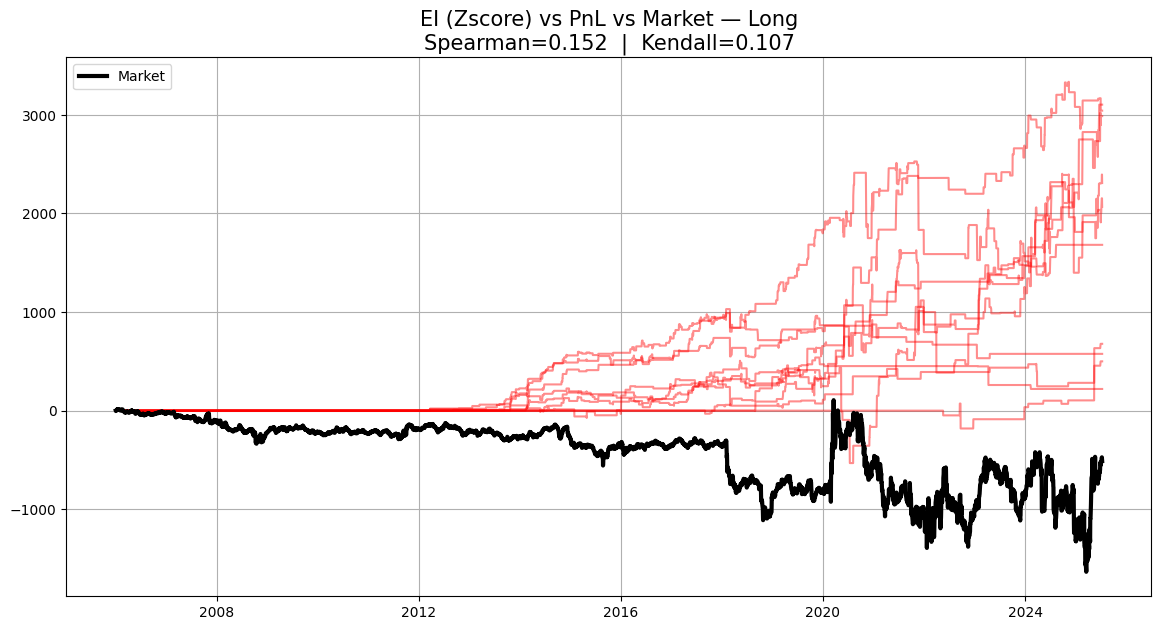

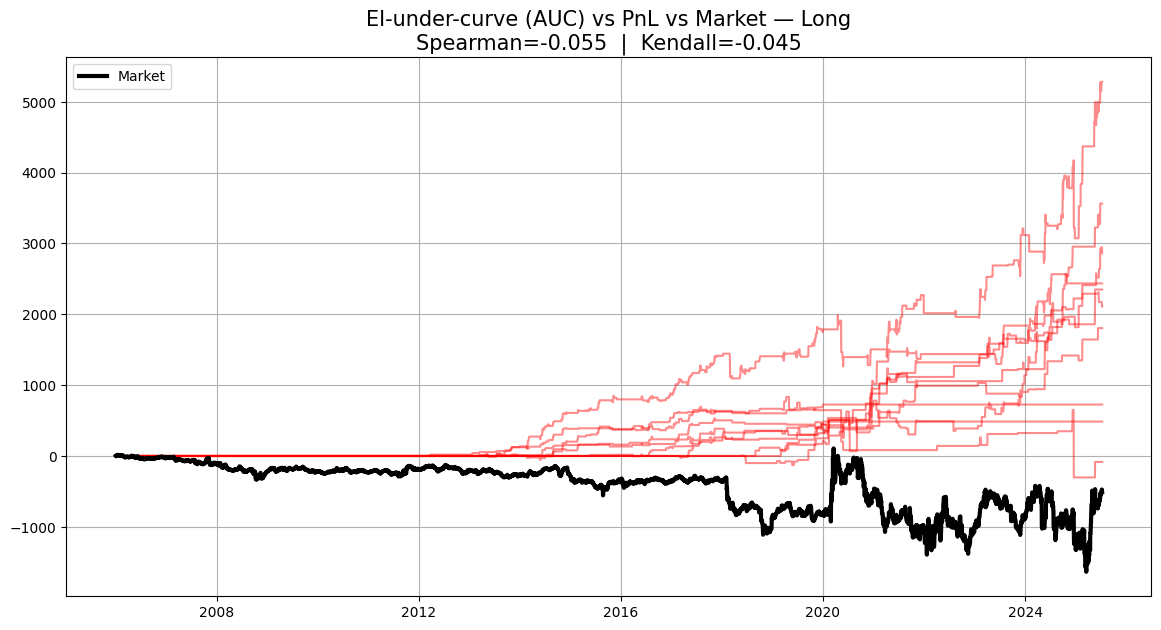

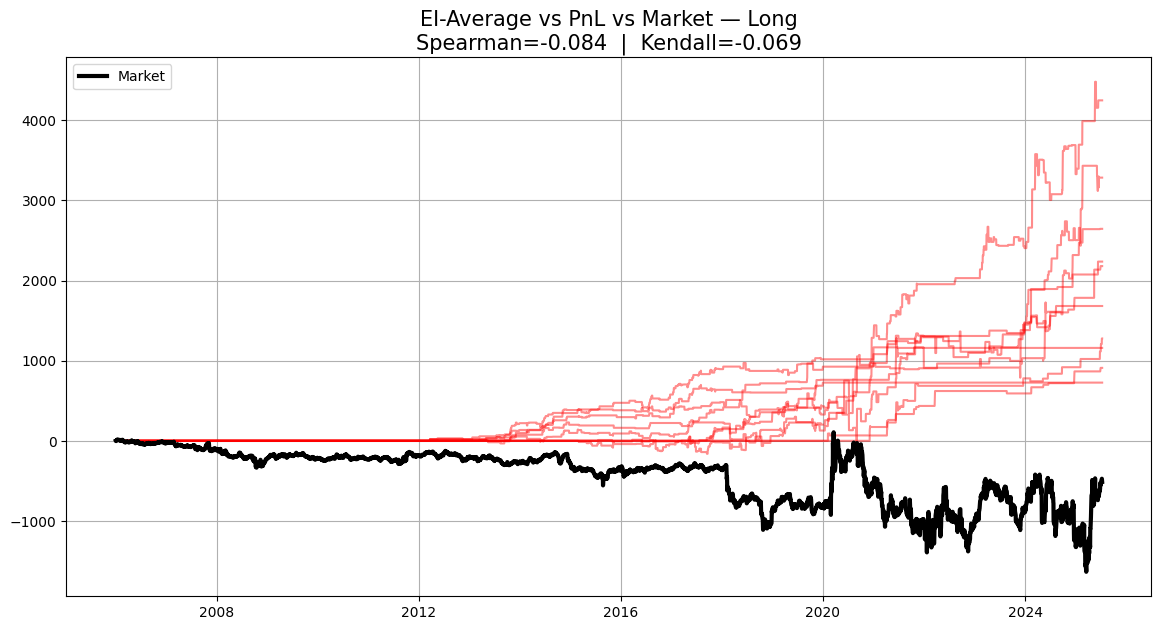

In [123]:
# 图 1 —— EI vs PnL vs Market
plot_ei_metric_vs_pnl_market(
    EI_long_zscore,                     # 或者 EI_long_minmax
    final_pnl_long,
    pnl_timeseries['long_pnl'],
    market_long,
    title="EI (Zscore) vs PnL vs Market — Long"
)

# 图 2 —— EI-AUC vs PnL vs Market
plot_ei_metric_vs_pnl_market(
    EI_auc_long_series,
    final_pnl_long,
    pnl_timeseries['long_pnl'],
    market_long,
    title="EI-under-curve (AUC) vs PnL vs Market — Long"
)

# 图 3 —— EI-average vs PnL vs Market
plot_ei_metric_vs_pnl_market(
    EI_average_long,
    final_pnl_long,
    pnl_timeseries['long_pnl'],
    market_long,
    title="EI-Average vs PnL vs Market — Long"
)


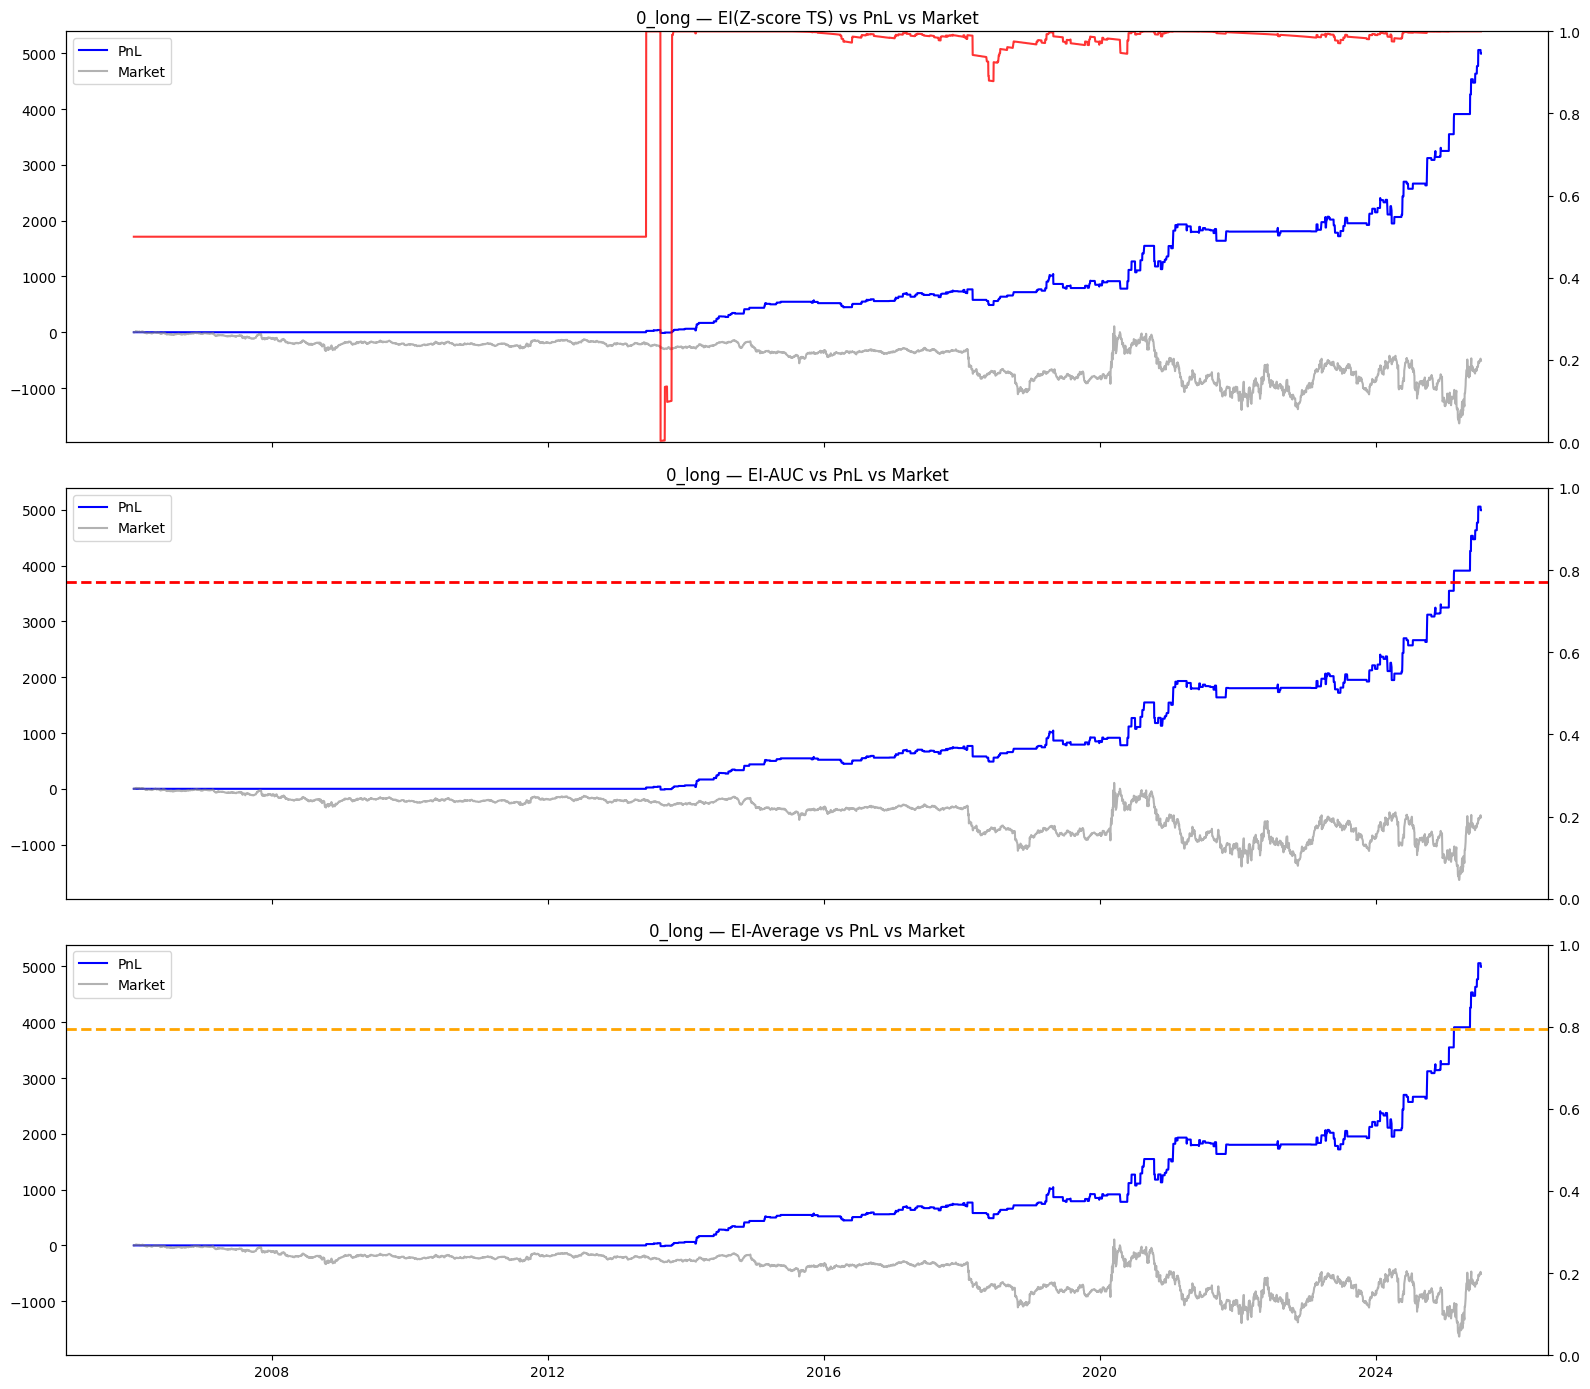

In [148]:
import matplotlib.pyplot as plt
import numpy as np

s = "0_long"

pnl    = pnl_timeseries['long_pnl'][s]
ei_ts  = ei_zscore_ts_long[s]
ei_avg = ei_ts.mean()
market = market_long

def ei_auc(ei, pnl):
    e, p = np.array(ei), np.array(pnl)
    n, agree, total = len(e), 0, 0
    for i in range(n):
        for j in range(i+1, n):
            if p[i] != p[j]:
                total += 1
                agree += ((e[i] > e[j]) and (p[i] > p[j])) or \
                         ((e[i] < e[j]) and (p[i] < p[j]))
    return agree/total if total > 0 else np.nan

ei_auc_val = ei_auc(ei_ts, pnl)

# -----------------------
#   Create 3×1 figure
# -----------------------
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

# ======================
# (1) EI TS
# ======================
ax1 = axes[0]
ax1.plot(pnl, c='blue', label="PnL")
ax1.plot(market, c='gray', alpha=0.6, label="Market")
ax2 = ax1.twinx()
ax2.plot(ei_ts, c='red', alpha=0.8, label="EI (TS)")
ax2.set_ylim(0,1)
ax1.legend(loc="upper left")
ax1.set_title(f"{s} — EI(Z-score TS) vs PnL vs Market")


# ======================
# (2) EI-AUC
# ======================
ax1 = axes[1]
ax1.plot(pnl, c='blue', label="PnL")
ax1.plot(market, c='gray', alpha=0.6, label="Market")
ax2 = ax1.twinx()
ax2.axhline(ei_auc_val, c='red', ls='--', lw=2, label=f"AUC={ei_auc_val:.3f}")
ax2.set_ylim(0,1)
ax1.legend(loc="upper left")
ax1.set_title(f"{s} — EI-AUC vs PnL vs Market")


# ======================
# (3) EI-Average
# ======================
ax1 = axes[2]
ax1.plot(pnl, c='blue', label="PnL")
ax1.plot(market, c='gray', alpha=0.6, label="Market")
ax2 = ax1.twinx()
ax2.axhline(ei_avg, c='orange', ls='--', lw=2, label=f"EI-Avg={ei_avg:.3f}")
ax2.set_ylim(0,1)
ax1.legend(loc="upper left")
ax1.set_title(f"{s} — EI-Average vs PnL vs Market")

plt.tight_layout()
plt.show()


## PCA分析EI，EI AUC，EI Ave中重要的成分有几个


In [152]:
import pandas as pd

# EI_Avg_Long 如果你还没跑，先跑这一段：
EI_avg_long_series = ei_distributional_ts_long.mean(axis=0)
EI_avg_long_series.name = "EI_Avg_Long"

# --- 构建 PCA 矩阵 ---
EI_features_long = pd.DataFrame({
    "EI_Z": EI_long_zscore,
    "EI_AUC": EI_auc_long_series,
    "EI_Avg": EI_avg_long_series
}).dropna()

print("EI_features_long shape:", EI_features_long.shape)
EI_features_long.head()


EI_features_long shape: (140, 3)


,EI_Z,EI_AUC,EI_Avg
0_long,0.458633,1.0,0.500098
1_long,0.348418,1.0,0.500098
4_long,0.078548,1.0,0.500098
5_long,0.183593,1.0,0.500098
6_long,0.153130,1.0,0.500098


In [153]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=3)
pca_values = pca.fit_transform(EI_features_long)

explained = pca.explained_variance_ratio_
print("PCA 解释度:", explained)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=EI_features_long.columns
)
print("\nLoadings:")
print(loadings)


PCA 解释度: [1.00000000e+00 2.46345089e-15 0.00000000e+00]

Loadings:
                 PC1           PC2           PC3
EI_Z    1.000000e+00 -6.664158e-16  8.029819e-16
EI_AUC  9.333338e-16  9.153482e-01 -4.026632e-01
EI_Avg -4.666669e-16  4.026632e-01  9.153482e-01


In [154]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pca_values)

EI_features_long["Cluster"] = clusters
print(EI_features_long.head())


            EI_Z  EI_AUC    EI_Avg  Cluster
0_long  0.458633     1.0  0.500098        0
1_long  0.348418     1.0  0.500098        0
4_long  0.078548     1.0  0.500098        2
5_long  0.183593     1.0  0.500098        2
6_long  0.153130     1.0  0.500098        2


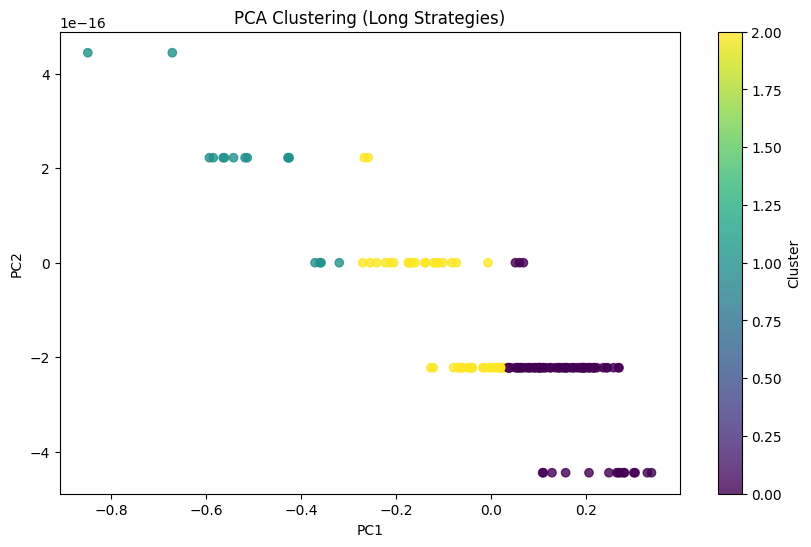

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(pca_values[:,0], pca_values[:,1], c=clusters, cmap="viridis", alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Clustering (Long Strategies)")
plt.colorbar(label="Cluster")
plt.show()


In [156]:
cluster_profiles = EI_features_long.groupby("Cluster").mean()
print("\n=== Cluster Profiles ===")
print(cluster_profiles)

count_table = EI_features_long["Cluster"].value_counts()
print("\n=== Cluster Sizes ===")
print(count_table)



=== Cluster Profiles ===
             EI_Z  EI_AUC    EI_Avg
Cluster                            
0        0.315867     1.0  0.500098
1       -0.348694     1.0  0.500098
2        0.062983     1.0  0.500098

=== Cluster Sizes ===
Cluster
0    78
2    46
1    16
Name: count, dtype: int64


## Clustering（多种办法）去看EI是否能代表PnL



In [159]:
# =======================
# 构建 PCA / Clustering 输入矩阵 X
# =======================

# 需要：EI_long_zscore, EI_auc_long_series, EI_avg_long_series

X = pd.DataFrame({
    "EI_Z": EI_long_zscore,
    "EI_AUC": EI_auc_long_series,
    "EI_Avg": EI_avg_long_series
}).dropna()   # 去掉任何缺失

from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
labels_km = kmeans.fit_predict(X)

X["Cluster_KMeans"] = labels_km
print(X.head())

            EI_Z  EI_AUC    EI_Avg  Cluster_KMeans
0_long  0.458633     1.0  0.500098               0
1_long  0.348418     1.0  0.500098               0
4_long  0.078548     1.0  0.500098               2
5_long  0.183593     1.0  0.500098               2
6_long  0.153130     1.0  0.500098               2


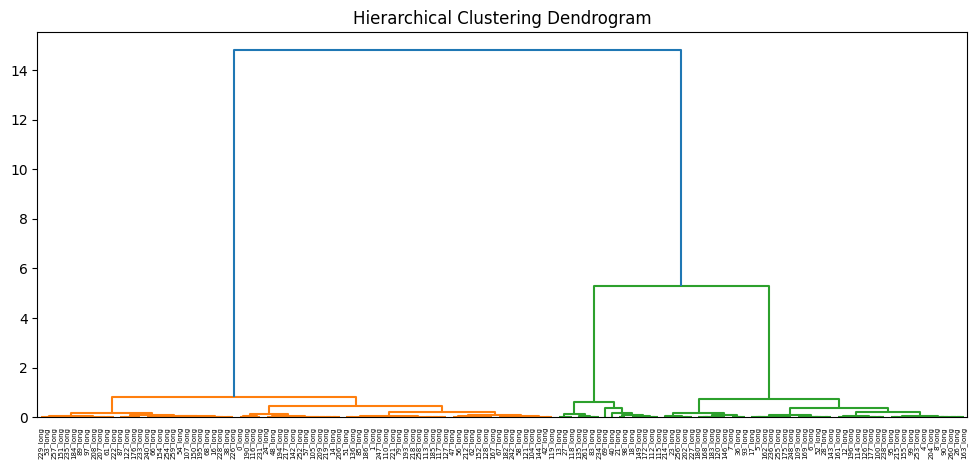

In [160]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(X, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, labels=X.index)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()


In [161]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.1, min_samples=3).fit(X)
X["Cluster_DBSCAN"] = db.labels_


In [162]:
from sklearn.cluster import SpectralClustering

sc = SpectralClustering(n_clusters=3, affinity='rbf', random_state=42)
labels_sc = sc.fit_predict(X)

X["Cluster_Spectral"] = labels_sc


In [174]:
# ================================
# 建立每个策略的最终 PnL 表
# ================================

pnl_summary = pnl_timeseries['long_pnl'].iloc[-1, :]   # 每个策略的最后一个 PnL
pnl_summary = pnl_summary.to_frame(name="Final_PnL")

print(pnl_summary.head())

for col in ["Cluster_KMeans","Cluster_DBSCAN","Cluster_Spectral"]:
    print("\n=== ", col, " ===")
    print(pnl_summary.groupby(X[col]).mean())


        Final_PnL
0_long     4993.0
1_long     3353.0
4_long     2350.0
5_long     3443.0
6_long     1146.0

===  Cluster_KMeans  ===
                  Final_PnL
Cluster_KMeans             
0               2247.461538
1               1626.500000
2               2267.217391

===  Cluster_DBSCAN  ===
                  Final_PnL
Cluster_DBSCAN             
-1               576.000000
 0              2247.461538
 1              2267.217391
 2              1696.533333

===  Cluster_Spectral  ===
                    Final_PnL
Cluster_Spectral             
0                 2267.217391
1                 1696.533333
2                 2226.303797


In [175]:
# 把 3 种 cluster 结果加进来
pnl_summary = pnl_summary.join(X[["Cluster_KMeans","Cluster_DBSCAN","Cluster_Spectral"]])



In [176]:
for col in ["Cluster_KMeans","Cluster_DBSCAN","Cluster_Spectral"]:
    print("\n簇内 PnL 方差：", col)
    print(pnl_summary.groupby(X[col]).std())



簇内 PnL 方差： Cluster_KMeans
                  Final_PnL  Cluster_KMeans  Cluster_DBSCAN  Cluster_Spectral
Cluster_KMeans                                                               
0               1264.870772             0.0            0.00              0.00
1               1293.443518             0.0            0.75              0.25
2               1422.859701             0.0            0.00              0.00

簇内 PnL 方差： Cluster_DBSCAN
                  Final_PnL  Cluster_KMeans  Cluster_DBSCAN  Cluster_Spectral
Cluster_DBSCAN                                                               
-1                      NaN             NaN             NaN               NaN
 0              1264.870772             0.0             0.0               0.0
 1              1422.859701             0.0             0.0               0.0
 2              1307.063823             0.0             0.0               0.0

簇内 PnL 方差： Cluster_Spectral
                    Final_PnL  Cluster_KMeans  Cluster_DBSC

## 用 EI filter，选出top 10 curve，和naive average 还可以选middle 10， last 10 对比）



In [177]:
# EI 选择器（你也可以换成 EI_long_minmax）
EI_used = EI_long_zscore.copy()

# 排序
EI_sorted = EI_used.sort_values(ascending=False)

# Top / Middle / Bottom 组
top10 = EI_sorted.index[:10]
mid10 = EI_sorted.index[len(EI_sorted)//2 - 5 : len(EI_sorted)//2 + 5]
bottom10 = EI_sorted.index[-10:]

print("Top 10:", list(top10))
print("Middle 10:", list(mid10))
print("Bottom 10:", list(bottom10))


Top 10: ['116_long', '231_long', '190_long', '0_long', '252_long', '142_long', '209_long', '219_long', '14_long', '206_long']
Middle 10: ['38_long', '16_long', '228_long', '54_long', '107_long', '150_long', '195_long', '254_long', '259_long', '122_long']
Bottom 10: ['118_long', '21_long', '98_long', '172_long', '112_long', '115_long', '18_long', '149_long', '40_long', '69_long']


In [178]:
naive_long = pnl_timeseries['long_pnl'].mean(axis=1)


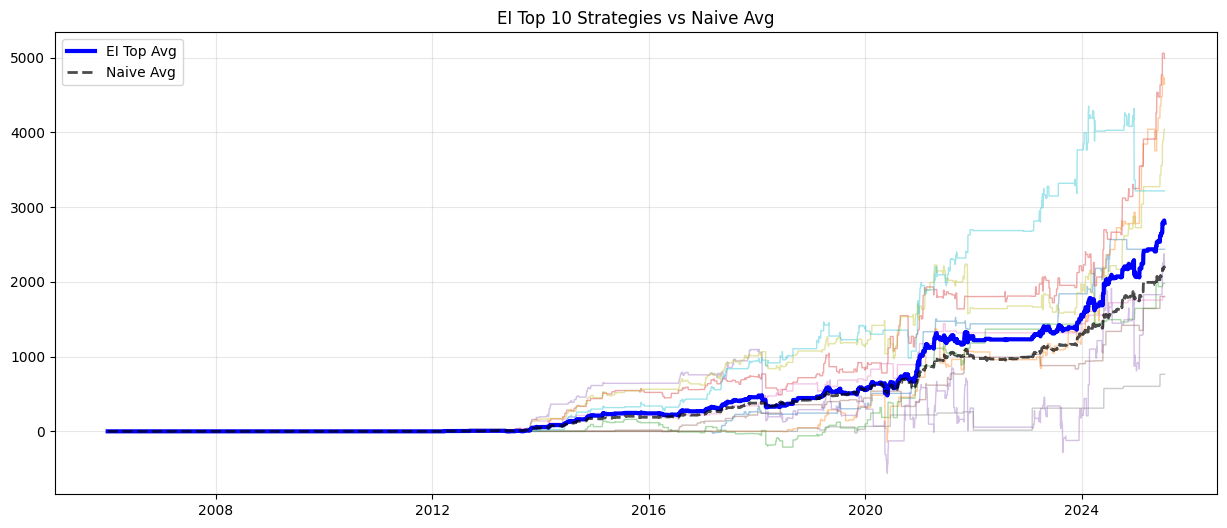

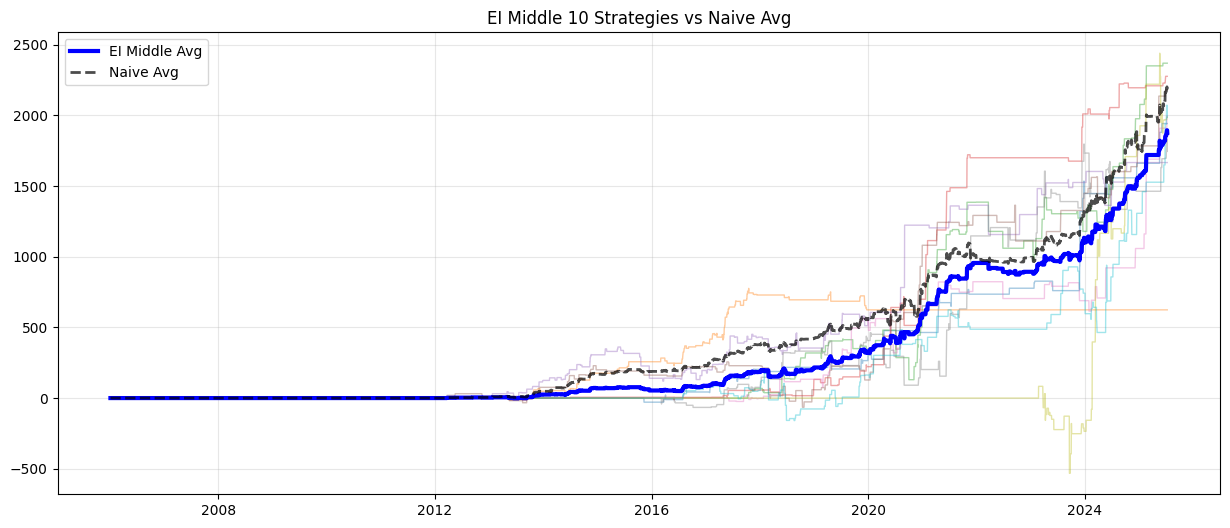

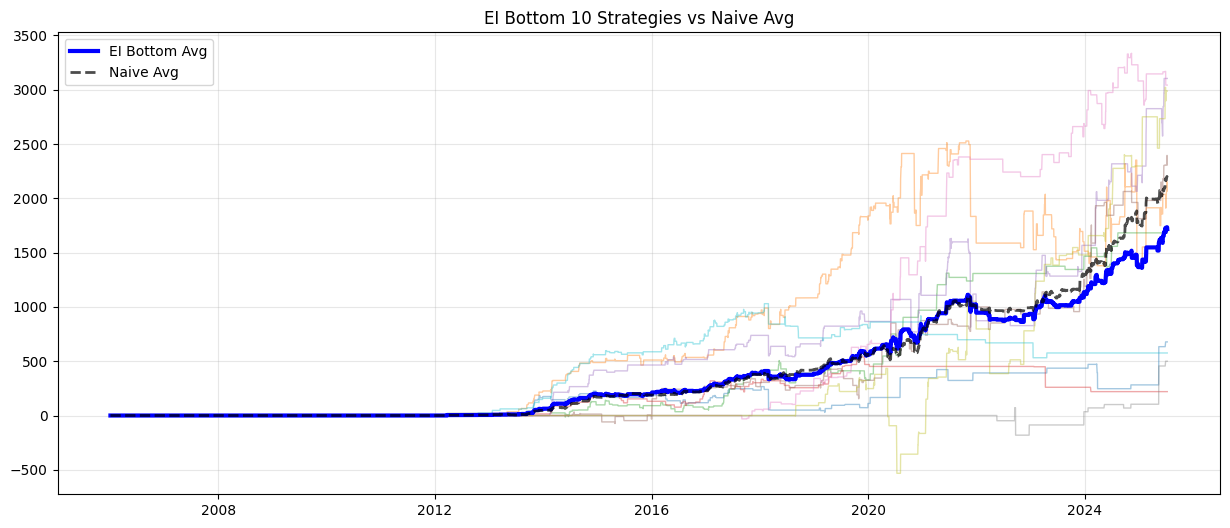

In [179]:
import matplotlib.pyplot as plt

def plot_group(group, title):
    plt.figure(figsize=(15,6))

    # group 策略曲线
    for s in group:
        plt.plot(pnl_timeseries['long_pnl'][s], alpha=0.4, lw=1)

    # group average（粗线）
    group_avg = pnl_timeseries['long_pnl'][group].mean(axis=1)
    plt.plot(group_avg, c='blue', lw=3, label=f"{title} Avg")

    # naive average baseline
    plt.plot(naive_long, c='black', lw=2, ls='--', alpha=0.7, label="Naive Avg")

    plt.title(f"{title} 10 Strategies vs Naive Avg")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# === 三张图 ===
plot_group(top10,   "EI Top")
plot_group(mid10,   "EI Middle")
plot_group(bottom10,"EI Bottom")
